In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r /content/drive/MyDrive/CyberSec_Data/data/data .

In [1]:
from IPython.display import display
import numpy as np
import os
import glob
import gc
import pandas as pd
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [32]:
random.seed(9)

In [2]:
path = "data/"
all_files = glob.glob(os.path.join(path, "*.csv"))

df_from_each_file = (pd.read_csv(f) for f in all_files)
df = pd.concat(df_from_each_file, ignore_index=True)
del df_from_each_file
gc.collect()

38

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [4]:
df.dropna(axis=1, how="all", inplace=True)

df = df.loc[:, df.apply(pd.Series.nunique) != 1]

In [5]:
df.dropna(axis=0, how="all", inplace=True)

In [6]:
df[" frequency"] = df.groupby(df.columns.tolist(), sort=False).cumcount()
df[" frequency"] = df[" frequency"].replace(np.nan, 0)
tmp_df_len = df.shape[0]
df.drop_duplicates(inplace=True)
display("Number of removed duplicates: ", tmp_df_len - df.shape[0])

display(df.sort_values(" frequency", ascending=False))

'Number of removed duplicates: '

1005

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,frequency
2465698,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9328.0
2464553,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9327.0
2464539,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9326.0
2464514,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9325.0
2464507,80,3,2,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,9324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985948,53,47244,1,1,45,201,45,45,45.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0.0
985949,53,213146,4,2,124,162,31,31,31.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0.0
985950,53,73347,1,1,47,242,47,47,47.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0.0
985951,53,23689,2,2,44,108,22,22,22.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0.0


In [7]:
df.replace([np.inf, -np.inf], -2, inplace=True)
df.replace(np.nan, -1, inplace=True)

In [8]:
# calculate the percentage of zeros in each column
zero_percentage = (df == 0).sum() / df.shape[0] * 100
display("Percentage of zeros in each column", zero_percentage)
zero_percentage = zero_percentage.drop(" frequency")  # we need the frequency column
columns_to_drop = zero_percentage[zero_percentage > 50].index.tolist()
display("Columns to drop", columns_to_drop)
df.drop(columns=columns_to_drop, inplace=True)

'Percentage of zeros in each column'

,0
Destination Port,0.059935
Flow Duration,0.065801
Total Fwd Packets,0.000000
Total Backward Packets,15.992081
Total Length of Fwd Packets,15.837685
...,...
Idle Std,91.898791
Idle Max,79.952808
Idle Min,79.952808
Label,0.000000


'Columns to drop'

[' Fwd Packet Length Std',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Std',
 ' Fwd IAT Std',
 ' Bwd IAT Std',
 'Fwd PSH Flags',
 ' Fwd URG Flags',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' PSH Flag Count',
 ' ACK Flag Count',
 ' URG Flag Count',
 ' CWE Flag Count',
 ' ECE Flag Count',
 'Active Mean',
 ' Active Std',
 ' Active Max',
 ' Active Min',
 'Idle Mean',
 ' Idle Std',
 ' Idle Max',
 ' Idle Min']

In [9]:
# calculate the percentage of -2 and -1 in each column
missing_percentage = (df == -2).sum() / df.shape[0] * 100
missing_percentage += (df == -1).sum() / df.shape[0] * 100
display("Percentage of missing values in each column", missing_percentage)
df = df.loc[:, missing_percentage <= 30]

'Percentage of missing values in each column'

,0
Destination Port,0.000000
Flow Duration,0.003923
Total Fwd Packets,0.000000
Total Backward Packets,0.000000
Total Length of Fwd Packets,0.000000
Total Length of Bwd Packets,0.000000
Fwd Packet Length Max,0.000000
Fwd Packet Length Min,0.000000
Fwd Packet Length Mean,0.000000
Bwd Packet Length Max,0.000000


In [10]:
df = df[(df != -1).all(axis=1)]
df = df[(df != -2).all(axis=1)]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2825095 entries, 0 to 2830742
Data columns (total 47 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9   Bwd Packet Length Max         int64  
 10   Bwd Packet Length Mean       float64
 11  Flow Bytes/s                  float64
 12   Flow Packets/s               float64
 13   Flow IAT Mean                float64
 14   Flow IAT Std                 float64
 15   Flow IAT Max                 int64  
 16   Flow IAT Min                 int64  
 17  Fwd IAT Total                 int64  
 18   Fwd IAT Mean              

In [12]:
df.columns = df.columns.str.strip()

In [13]:
print("Unique label values:")
print(df["Label"].unique())

Unique label values:
['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration'
 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed']


In [21]:
df["Label"] = df["Label"].str.replace("�", "-", regex=False)

In [22]:


features = df.drop(columns=["Label"])
label = df["Label"]

le = LabelEncoder()
encoded_labels = le.fit_transform(label)  # creates multiclass label encoding
decoded_labels = le.inverse_transform(encoded_labels)

print("Encoded classes:", le.classes_)



Encoded classes: ['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack - Brute Force' 'Web Attack - Sql Injection'
 'Web Attack - XSS']


In [15]:
binary_labels = np.where(df["Label"] == "BENIGN", 0, 1)

unique, counts = np.unique(binary_labels, return_counts=True)
print("Binary label distribution:", dict(zip(unique, counts)))

Binary label distribution: {0: 2268719, 1: 556376}


In [23]:
features = features.astype(float)

In [24]:


scaler = StandardScaler()
features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

df = pd.concat([features, pd.DataFrame(label, columns=["Label"])], axis=1)

---

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2830742 entries, 0 to 2830742
Data columns (total 47 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             float64
 1   Flow Duration                float64
 2   Total Fwd Packets            float64
 3   Total Backward Packets       float64
 4   Total Length of Fwd Packets  float64
 5   Total Length of Bwd Packets  float64
 6   Fwd Packet Length Max        float64
 7   Fwd Packet Length Min        float64
 8   Fwd Packet Length Mean       float64
 9   Bwd Packet Length Max        float64
 10  Bwd Packet Length Mean       float64
 11  Flow Bytes/s                 float64
 12  Flow Packets/s               float64
 13  Flow IAT Mean                float64
 14  Flow IAT Std                 float64
 15  Flow IAT Max                 float64
 16  Flow IAT Min                 float64
 17  Fwd IAT Total                float64
 18  Fwd IAT Mean                 float64
 19  Fwd I

In [26]:
# Map Features to Signals
signal_mapping = {
    "Fwd Packet Length Max": "PAMP",
    "Bwd Packet Length Max": "PAMP",
    "Packet Length Variance": "PAMP",

    "Flow IAT Mean": "Danger",
    "Total Fwd Packets": "Danger",
    "Flow Duration": "Danger",

    "Fwd IAT Min": "Safe",
    "Min Packet Length": "Safe",
    "Fwd Packet Length Min": "Safe"
}

# Map signals
signals = {
    signal_type: features[feature_name]
    for feature_name, signal_type in signal_mapping.items()
}

In [27]:
class DendriticCell:
    def __init__(self, lifespan=100):
        self.csm = 0
        self.k = 0
        self.data_indices = []
        self.lifespan = lifespan
        self.age = 0

    def process(self, index, pamp, danger, safe):
        self.age += 1
        self.csm += pamp + danger + safe
        self.k += pamp + danger - 2 * safe  # Simple k-value rule
        self.data_indices.append(index)

    def is_mature(self):
        return self.age >= self.lifespan

In [31]:
num_cells = 100
cells = [DendriticCell(random.randint(80, 120)) for _ in range(num_cells)]

context_table = {}
k_values_by_index = {}

for i in range(len(features)):
    pamp = signals["PAMP"].iloc[i]
    danger = signals["Danger"].iloc[i]
    safe = signals["Safe"].iloc[i]

    # Randomly pick a subset of DCs to process the sample
    active_cells = random.sample(cells, k=int(num_cells * 0.1))

    for dc in active_cells:
        dc.process(i, pamp, danger, safe)

        if dc.is_mature():
            context = 1 if dc.k > 0 else 0  # 1: anomalous, 0: normal
            for idx in dc.data_indices:
                context_table.setdefault(idx, []).append(context)
                k_values_by_index.setdefault(idx, []).append(dc.k)
            # reset cell
            dc.__init__(random.randint(80, 120))

In [33]:
y_true = label
y_pred = []

for i in range(len(features)):
    votes = context_table.get(i, [])
    if not votes:
        pred = 0  # Default to normal
    else:
        pred = 1 if sum(votes)/len(votes) > 0.5 else 0
    y_pred.append(pred)


In [34]:
from sklearn.metrics import classification_report

print("=== DCA Binary Classification Report ===")
print(classification_report(binary_labels, y_pred, target_names=["BENIGN", "ATTACK"]))

=== DCA Binary Classification Report ===
              precision    recall  f1-score   support

      BENIGN       0.91      0.88      0.89   2268719
      ATTACK       0.57      0.63      0.60    556376

    accuracy                           0.83   2825095
   macro avg       0.74      0.76      0.75   2825095
weighted avg       0.84      0.83      0.84   2825095



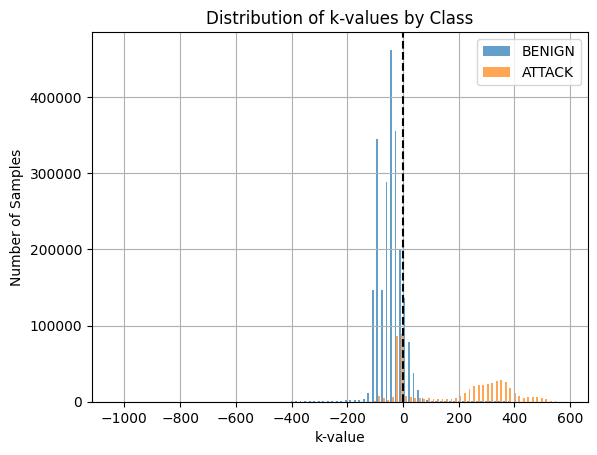

In [35]:
import matplotlib.pyplot as plt

k_avg = []
labels_for_k = []

for idx in k_values_by_index:
    if idx < len(binary_labels):
        avg_k = np.mean(k_values_by_index[idx])
        k_avg.append(avg_k)
        labels_for_k.append(binary_labels[idx])  # 0 = BENIGN, 1 = ATTACK

# Separate by class
k_benign = [k for k, lbl in zip(k_avg, labels_for_k) if lbl == 0]
k_attack = [k for k, lbl in zip(k_avg, labels_for_k) if lbl == 1]

# Plot
plt.hist([k_benign, k_attack], bins=100, label=["BENIGN", "ATTACK"], alpha=0.7)
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of k-values by Class")
plt.xlabel("k-value")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(True)
plt.show()
